In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib Inline
%config InlineBackend.figure_format = "svg"
sns.set(rc={'axes.facecolor':'#ebeaf1', 'figure.facecolor':'lightgrey'})

In [2]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [3]:
df_train.drop("Id", axis=1, inplace=True)
df_test.drop("Id", axis=1, inplace=True)

## EDA (Exploratory Data Analysis)

### Target variable and base statistics

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  float64
 1   years_of_experience  10000 non-null  float64
 2   lesson_price         10000 non-null  float64
 3   qualification        10000 non-null  float64
 4   physics              10000 non-null  float64
 5   chemistry            10000 non-null  float64
 6   biology              10000 non-null  float64
 7   english              10000 non-null  float64
 8   geography            10000 non-null  float64
 9   history              10000 non-null  float64
 10  mean_exam_points     10000 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 859.5 KB


* **Id** - unique identifier
* **age** - Age of tutor
* **years_of_experience**
* **lesson_price**
* **qualification**
* **physics** - teaches physics
* **chemistry** - teaches chemistry
* **biology** - teaches biology
* **english** - teaches english
* **geography** - teaches geography
* **history** - teaches history
* **mean_exam_points** - target feature

### EDA (Exploratory data analysis)

### Target variable and base statistic

In [17]:
df_train.describe()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.878000,1.986800,1699.105000,1.719500,0.375000,0.132900,0.109600,0.053700,0.032100,0.019400,63.737300
std,8.043929,1.772213,524.886654,0.792264,0.484147,0.339484,0.312406,0.225436,0.176274,0.137933,14.705574
min,23.000000,0.000000,200.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000
25%,40.000000,0.000000,1300.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,53.000000
50%,46.000000,2.000000,1500.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,63.000000
75%,51.000000,3.000000,2150.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,74.000000
max,68.000000,10.000000,3950.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000


In [18]:
df_train.head()

,age,years_of_experience,lesson_price,qualification,physics,chemistry,biology,english,geography,history,mean_exam_points
0,40.0,0.0,1400.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,61
1,48.0,4.0,2850.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,76
2,39.0,0.0,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,53
3,46.0,5.0,1400.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,54
4,43.0,1.0,1500.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,57


In [4]:
def reduce_mem_usage(df):
    """
    Iterate through all the columns of a dataframe and modify the data type
    to reduce memory usage
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print("Memory usage of dataframe is {:.2f} MB".format(start_mem))
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == "int":
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                      df[col] = df[col].astype(np.float64)  
        else:
            df[col] = df[col].astype("category")
    end_mem = df.memory_usage().sum() /1024**2
    print("Memory usage after optimization is: {:.2f} MB".format(end_mem))
    print("Decreased by {:.1f}%".format(100 * (start_mem - end_mem) / start_mem))
    return df

In [5]:
df_train = reduce_mem_usage(df_train)

Memory usage of dataframe is 0.84 MB
Memory usage after optimization is: 0.39 MB
Decreased by 53.4%


Take a look on our target feature

In [42]:
def measures_of_the_central_trend(data: pd.Series):
    mean_ = data.mean()
    median_ = data.median()
    mode_ = data.mode()[0]
    return mean_, median_, mode_

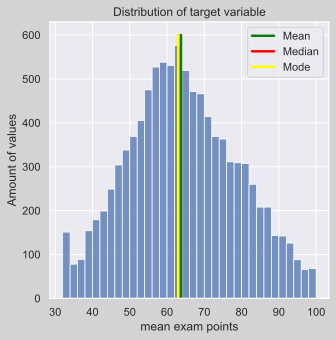

In [65]:
target_mean, target_median, target_mode = measures_of_the_central_trend(df_train["mean_exam_points"])
y = np.linspace(0, 600, 600)

plt.figure(figsize=(5, 5))

sns.histplot(data=df_train, x="mean_exam_points",bins=34)
plt.plot([target_mean] * 600, y, color="green", label="Mean", linewidth=2.5)
plt.plot([target_median] * 600, y, color="red", label="Median", linewidth=2.5)
plt.plot([target_mode] * 600, y, color="yellow", label="Mode", linewidth=2.5)

plt.xlabel("mean exam points")
plt.ylabel("Amount of values")
plt.title("Distribution of target variable")
plt.legend(loc="upper right")

plt.show()

The distribution of target variable appears to be normal. The majority of data concentrated in the middle of the chart. Mean, median and mode are almost at same point.

### Continuous variables

#### Age

In [55]:
age_mean, age_median, age_mode = measures_of_the_central_trend(df_train["age"])
print(f"Measures of the central trend for Age:\nMean - {age_mean}\nMode - {age_mode}\nMedian - {age_median}")

Measures of the central trend for Age:
Mean - 45.87799835205078
Mode - 48.0
Median - 46.0


<Figure size 300x300 with 0 Axes>

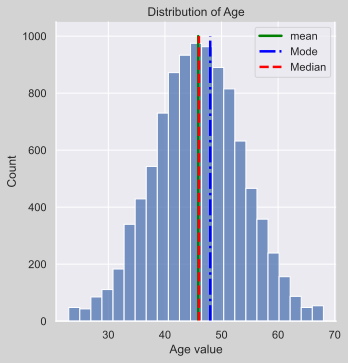

In [308]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1000, 1000)
sns.displot(df_train["age"], bins=23, kde=False)
plt.plot([age_mean] * 1000, y, color="green", linewidth=2.5, label="mean")
plt.plot([age_mode] * 1000, y, color="blue", linewidth=2.5, label="Mode", linestyle="-.")
plt.plot([age_median] * 1000, y, color="red", linewidth=2.5, label="Median", linestyle="dashed")

plt.title("Distribution of Age")
plt.ylabel("Count")
plt.xlabel("Age value")
plt.legend(loc="upper right")

plt.show()

#### Lesson price

In [67]:
lesson_price_mean, lesson_price_median, lesson_price_mode = measures_of_the_central_trend(df_train["lesson_price"])
print(f"Measures of the central trend for lesson_price:\nMean - {lesson_price_mean}\nMode - {lesson_price_mode}\nMedian - {lesson_price_median}")

Measures of the central trend for lesson_price:
Mean - 1699.10498046875
Mode - 1450.0
Median - 1500.0


<Figure size 300x300 with 0 Axes>

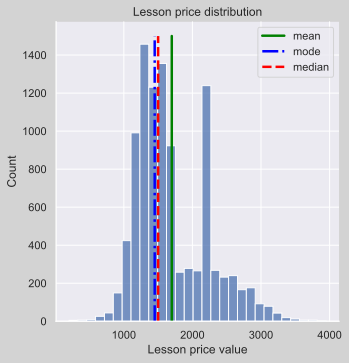

In [307]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1500, 1500)
sns.displot(df_train["lesson_price"], bins=29, kde=False)
plt.plot([lesson_price_mean] * 1500, y, color="green", linewidth=2.5, label="mean")
plt.plot([lesson_price_mode] * 1500, y, color="blue", linewidth=2.5, linestyle="-.", label="mode")
plt.plot([lesson_price_median] * 1500, y, color="red", linewidth=2.5, linestyle="dashed", label="median")

plt.title("Lesson price distribution")
plt.ylabel("Count")
plt.xlabel("Lesson price value")
plt.legend(loc="upper right")

plt.show()

According to the histograms, The Age distribution tends to be normal, measures of the central trand are located quite close to each other. The most common age for this data set is in the region of 48. The data in Lesson price distribution are different. The most popular tutors have lesson price between 1000 and 2000. Mode and median in this feature are located at almost the same point, mean value is a bit shifted beacause the data

The yongest tutor is 23 years old and the oldest is 68. The cheapest lesson price is 200, the most expensive - 3950. Based on chart tutors with this lesson price are quite rare, it can be outliers.

Now we should use box plot in order to give a first sight on outliers and calc quartiles

In [112]:
def calculate_quantiles(data):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    IQR = q3 - q1
    return q1, q3, IQR

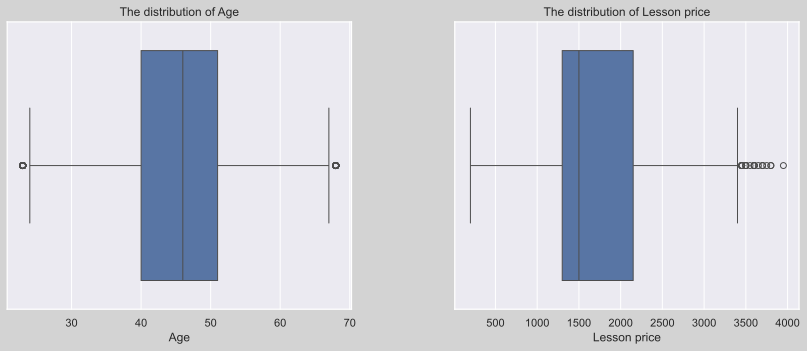

In [106]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5), 
    gridspec_kw={'left': 0, 'right': 1.1, 'top': 1, 'bottom': 0.2}
)

ax1, ax2 = axes.flatten()

sns.boxplot(data=df_train, ax=ax1, x="age")
ax1.set_xlabel("Age")
ax1.set_title("The distribution of Age")

sns.boxplot(data=df_train, ax=ax2, x="lesson_price")
ax2.set_xlabel("Lesson price")
ax2.set_title("The distribution of Lesson price")

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

In [118]:
age_q1, age_q3, age_iqr = calculate_quantiles(df_train["age"])
lp_q1, lp_q3, lp_iqr = calculate_quantiles(df_train["lesson_price"])

print(f"Age Q1 - {age_q1}, Q3 - {age_q3}, IQR - {age_iqr}")
print(f"Lesson Price Q1 - {lp_q1}, Q3 - {lp_q3}, IQR - {lp_iqr}\n")

age_low_limit = age_q1 - age_iqr * 1.5
age_high_limit = age_q3 + age_iqr * 1.5

lp_low_limit = lp_q1 - lp_iqr * 1.5
lp_high_limit = lp_q3 + lp_iqr * 1.5

print(f"Low limit for the Age feature is {age_low_limit} High limit - {age_high_limit}")
print(f"Low limit for the Lesson price feature is {lp_low_limit} High limit - {lp_high_limit}")

Age Q1 - 40.0, Q3 - 51.0, IQR - 11.0
Lesson Price Q1 - 1300.0, Q3 - 2150.0, IQR - 850.0

Low limit for the Age feature is 23.5 High limit - 67.5
Low limit for the Lesson price feature is 25.0 High limit - 3425.0


#### Years of experience

<Figure size 300x300 with 0 Axes>

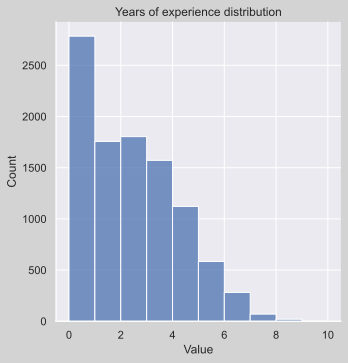

In [306]:
plt.figure(figsize=(3, 3))

y = np.linspace(0, 1500, 1500)
sns.displot(df_train["years_of_experience"], bins=10, kde=False)

plt.title("Years of experience distribution")
plt.ylabel("Count")
plt.xlabel("Value")

plt.show()

The majority of tutors do not have experience. 
The biggest number of tuturs within all teachers is the tutors who do not have experience. The years of experience distribution appears to be the step with plato since 1 to 3 years. According this chart tutors with 7 and more years of experience are the rarest.

### Categorical variables

In [129]:
category = ["physics", "chemistry", "biology", "english", "geography", "history"]

In [148]:
df_category = df_train[category]

count_category = df_category.apply(lambda x: sum([i for i in x]), axis=0)
count_category["no_one_category"] = df_category.apply(lambda x: sum([1 if i == 0 else 0 for i in x]) == 6, axis=1).sum()

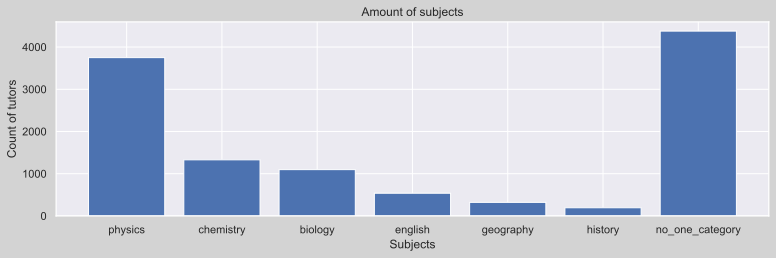

In [305]:
fig, ax = plt.subplots(figsize=(9, 3))

fig.subplots_adjust(left=0, right=1.1, top=1, bottom=0.1)

ax.bar(count_category.index, count_category)
ax.set_xlabel("Subjects")
ax.set_ylabel("Count of tutors")
ax.set_title("Amount of subjects")

plt.show()

The most popular subject is physics - above 3500, unpopular is history - less 500. Chemistry and biology are located almost at the same level - 1200. But the biggest number tutors is tutors who do not have subjects (more than 4300)

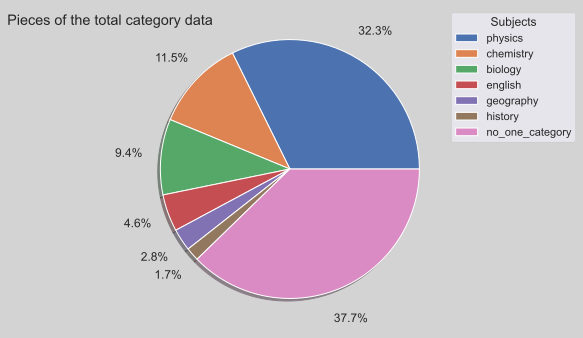

In [236]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

fig.suptitle("Pieces of the total category data")
fig.subplots_adjust(left=0, right=2, top=1, bottom=0.1)

axes.pie(
    x=count_category,
    autopct="%1.1f%%",
    pctdistance=1.25,
    labeldistance=.5,
    shadow=True
)
axes.legend(
    title="Subjects",
    labels=count_category.index,
    bbox_to_anchor=(0.9, 0, 0.5, 1),
)

plt.show()

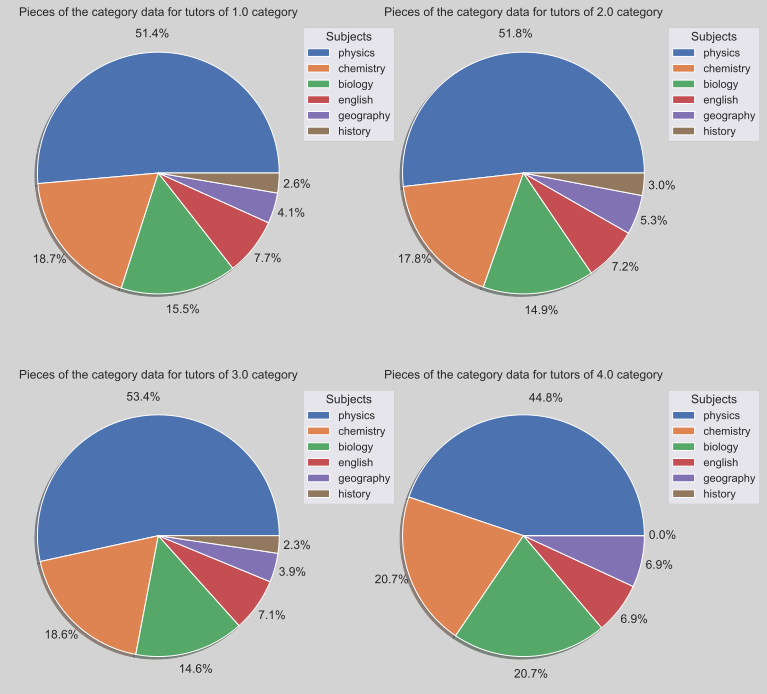

In [262]:
category_grouped = df_train.groupby(by="qualification").agg(
    physics_count = ("physics", "sum"),
    chemistry_count = ("chemistry", "sum"),
    biology_count = ("biology", "sum"),
    english_count = ("english", "sum"),
    geography_count = ("geography", "sum"),
    history_count = ("history", "sum")
)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

ax1, ax2, ax3, ax4 = axes.flatten()

for idx, row in category_grouped.iterrows():
    ax = axes[int(idx - 1) // 2, int(idx - 1) % 2]

    labels = [label.replace("_count", "") for label in row.index]
    
    ax.pie(
        x=row,
        autopct="%1.1f%%",
        pctdistance=1.15,
        labeldistance=.5,
        shadow=True
    )
    ax.legend(
        title="Subjects",
        labels=labels,
        bbox_to_anchor=(0.8, 0.2, 0.5, 0.8),
    )
    
    ax.set_title(f"Pieces of the category data for tutors of {idx} category")


The amount of tutors who teach particular subject in all qualifications stays almost at the same level. The only one qualification wich showed the difference is 4. There is no tutors who teach history and amount of tutors who teach physics is less than in the different qualifications. These two factors allowed the rest subjects to be increased

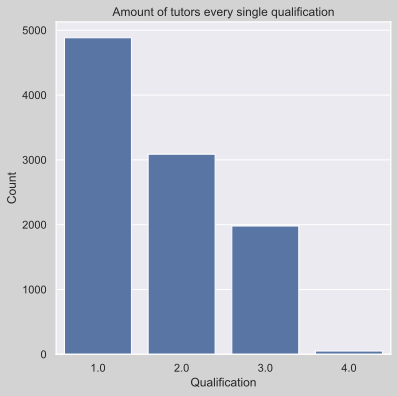

In [309]:
plt.figure(figsize=(6, 6))

sns.countplot(
    data=df_train,
    x="qualification"
)

plt.xlabel("Qualification")
plt.ylabel("Count")
plt.title("Amount of tutors every single qualification")

plt.show()

Majority of tutors is tutors of 1 qualification. Forth qualification appears to be the rarest, it can be connected with the difficulty of getting this qualification

### Interaction with the target variable and each other

In [319]:
def show_subject_tutor_distribution_by_experience_and_qualification(df, subjects, qualification):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(11, 8))
    fig.suptitle(f"Tutors of {qualification} qualification who teach subjects by years of experience")
    
    for idx, subject in enumerate(subjects):
        ax = axes[idx // 3, idx % 3]
        
        subject_df = df[(df["qualification"] == qualification) & (df[subject] == 1)]
        
        all_years = sorted(subject_df["years_of_experience"].unique())
        
        years = []
        scores = []
        
        for year in all_years:
            data = subject_df[(subject_df["years_of_experience"] == year)]
            if not data.empty:
                years.append(year)
                scores.append(data["mean_exam_points"].mean())
        
        x = np.arange(len(all_years))
        width = 0.35
        
        ax.bar(x, scores, width, alpha=0.7)
        
        ax.set_xlabel("Years of experience")
        ax.set_ylabel("Mean exam points")
        ax.set_title(f"{subject}")
        
    plt.tight_layout()
    plt.show()

<Figure size 200x200 with 0 Axes>

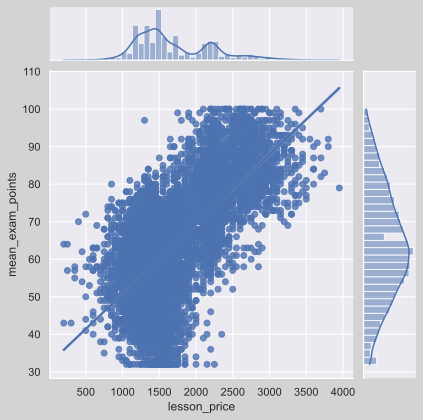

In [273]:
plt.figure(figsize=(2, 2))

sns.jointplot(data=df_train, x="lesson_price", y="mean_exam_points", kind="reg")

plt.show()

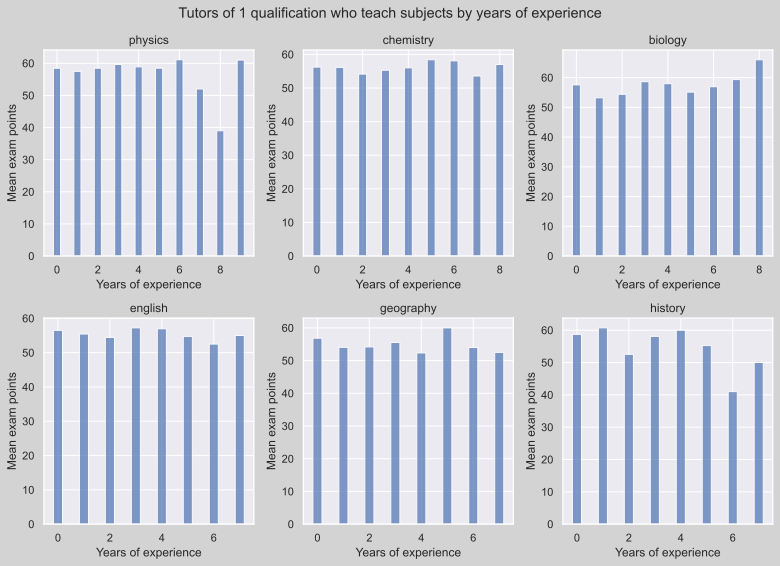

In [320]:
show_subject_tutor_distribution_by_experience_and_qualification(df_train, category, 1)

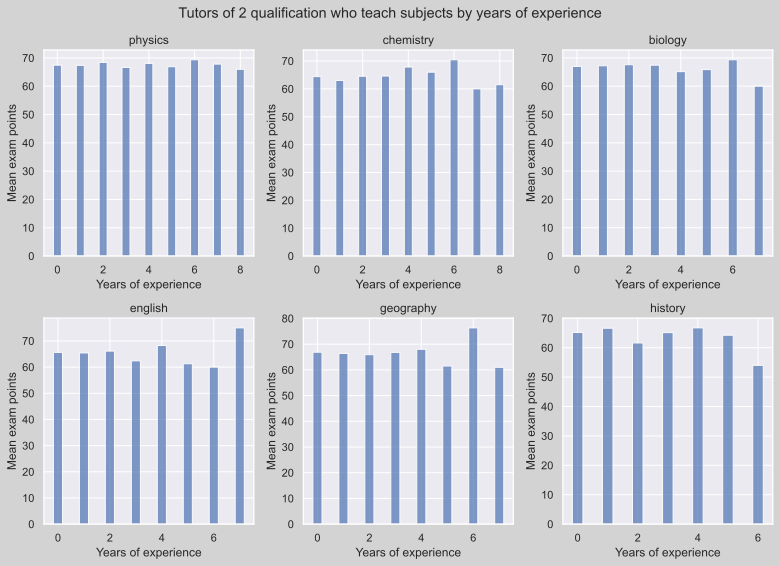

In [321]:
show_subject_tutor_distribution_by_experience_and_qualification(df_train, category, 2)

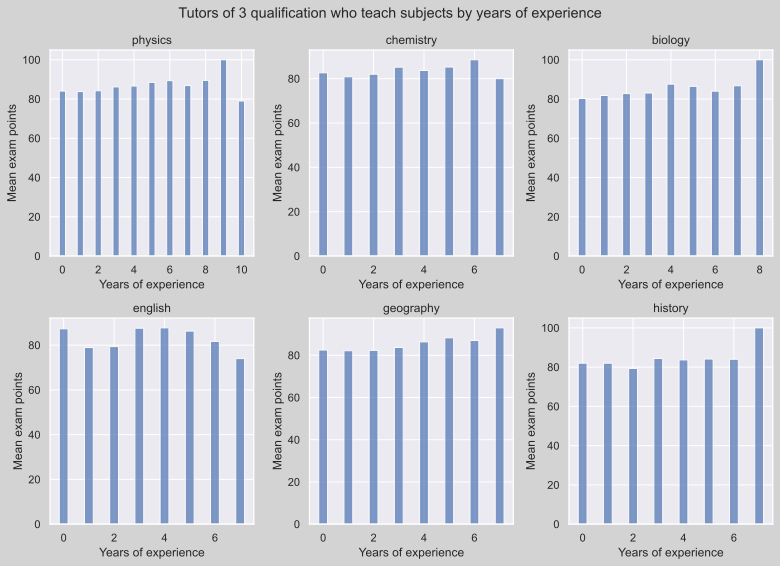

In [322]:
show_subject_tutor_distribution_by_experience_and_qualification(df_train, category, 3)

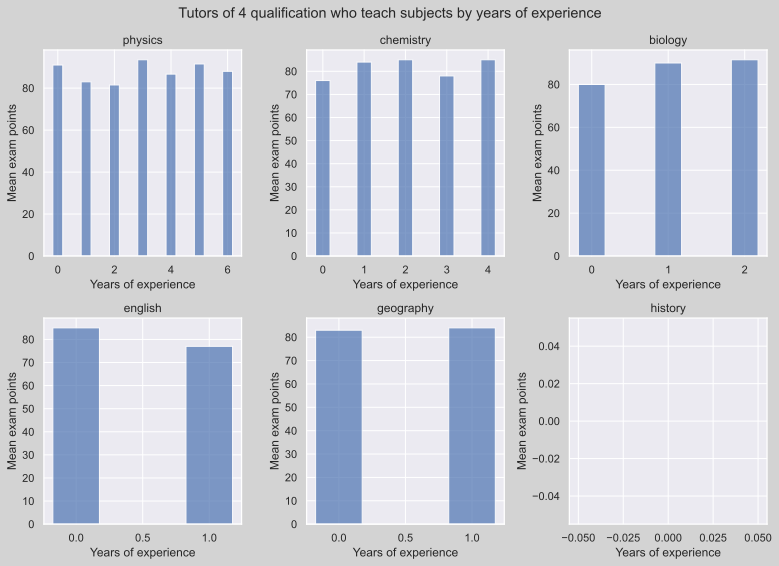

In [323]:
show_subject_tutor_distribution_by_experience_and_qualification(df_train, category, 4)

The upward trend can be seen between lesson price and mean exam points. As the lesson price grows, the mean exam points increases too.

As Regards mean exam points in different qualifications groups, we can make next outcomes:
- The maximum exam points in average for tutors of 1 qualification in spite of experience is a bit more than 60. The biggest variance in the average exam scores within all years of experience turned out to be in History subject
- Scores in 2 qualification a bit higher but still quite low. Despite this fact, tutors in this category who teach geography and have 6 years of experience managed to reach of 80 points in average.
- The difference in preparation to exam between third qualification and previous displayed on the average exam points. The minimus exam points in average for tutor of 3 qualification is 80.
- The numbor of tutors of 4 qualification is quite small. Nevertheless, the average exam points in this qualification do not surpass scorea of 3 qualification.

Still there is not clear upward trend in years of experience. A lot of experience is not an indicator of high scores. There is no linear connection between years of experience and mean exam points

<Figure size 400x400 with 0 Axes>

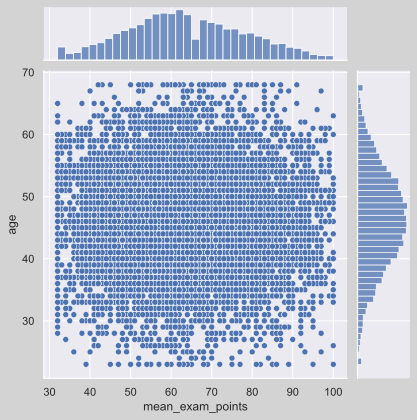

In [325]:
plt.figure(figsize=(4, 4))

sns.jointplot(data=df_train, x="mean_exam_points", y="age")

plt.show()

Accorring the chart above, there is no big difference for tutor age. The Student with young tutor can reach high score as well as old. At least there is no the lenear connection, but maybe should try make combination using different features

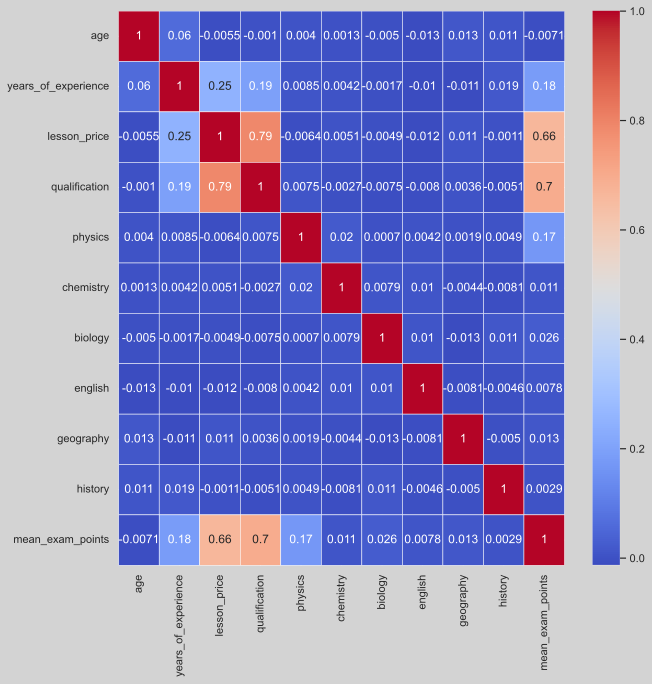

In [329]:
plt.figure(figsize=(10, 10))

corr_matrix = np.round(df_train.corr(), 4)

sns.heatmap(data=corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)

plt.show()

The Heat map chart proved outcomes made before:
- There is big correlation between mean exam point and qualification (0.7), mean exam point and lesson price (0.66), qualification and lesson price (0.79).
- There is no the linear connetion between age and mean exam point, year of experience and mean exam point. But should try the combination of these features. 

## BaseLine model

In [6]:
class Node:

    def __init__(self, t, idx, true_branch, false_branch):
        self.t = t
        self.idx = idx
        self.true_branch = true_branch
        self.false_branch = false_branch


class Leaf:

    def __init__(self, targets):
        # self.data = data
        self.targets = targets
        self.prediction = self.make_prediction()

    def make_prediction(self):
        prediction = self.targets.mean()
        return prediction


class DecisionTree:

    def __init__(self, max_depth=10, min_sample_leaf=5):
        self.max_depth = max_depth
        self.min_sample_leaf = min_sample_leaf

    # def gini(self, labels):
    #     classes = {}

    #     for cls in labels:
    #         if cls not in classes:
    #             classes[cls] = 0
    #         classes[cls] += 1

    #     impurity = 1
    #     for label in classes:
    #         p = classes[label] / len(labels)
    #         impurity -= p**2
    #     return impurity

    def mse(self, targets):
        return np.mean((targets - np.mean(targets))**2)

    def gain(self, left_targets, right_targets, root_mse, criterion):
        p = float(left_targets.shape[0]) / (left_targets.shape[0] + right_targets.shape[0])
        return root_mse - criterion(left_targets) * p - criterion(right_targets) * (1 - p)

    def split(self, t, column_idx, targets, data):
        left = np.where(data[:, column_idx] <= t)
        right = np.where(data[:, column_idx] > t)

        true_data = data[left]
        false_data = data[right]

        true_targets = targets[left]
        false_targets = targets[right]

        return true_data, false_data, true_targets, false_targets

    def find_best_split(self, data, targets):

        root_mse = self.mse(targets)

        best_gain = 0
        best_t = None
        best_index = None

        n_fetures = data.shape[1]

        for idx in range(n_fetures):
            t_values = np.unique(data[:, idx])

            for t in t_values:
                true_data, false_data, true_targets, false_targets = self.split(t=t, column_idx=idx, targets=targets, data=data)
                if len(true_data) < self.min_sample_leaf or len(false_data) < self.min_sample_leaf:
                    continue
                
                current_gain = self.gain(left_targets=true_targets, right_targets=false_targets, root_mse=root_mse, criterion=self.mse)

                if current_gain > best_gain:
                    best_gain, best_t, best_index = current_gain, t, idx
                    
        return best_gain, best_t, best_index

    def predict_object(self, obj, node):

        if isinstance(node, Leaf):
            answer = node.prediction
            return answer
            
        elif obj[node.idx] <= node.t:
            return self.predict_object(obj, node.true_branch)
        elif obj[node.idx] > node.t:
            return self.predict_object(obj, node.false_branch)

    def predict(self, data, tree):
    
        predicts = []
        for obj in data:
            prediction = self.predict_object(obj, tree)
            predicts.append(prediction)
        return predicts

    def build_tree(self, data, targets, current_depth=0):
        if current_depth >= self.max_depth:
            return Leaf(targets=targets)
        gain, t, idx = self.find_best_split(data=data, targets=targets)

        if gain == 0:
            return Leaf(targets=targets)
        true_data, false_data, true_targets, false_targets = self.split(t=t, column_idx=idx, targets=targets, data=data)

        true_branch = self.build_tree(data=true_data, targets=true_targets, current_depth=current_depth + 1)
        false_branch = self.build_tree(data=false_data, targets=false_targets, current_depth=current_depth + 1)

        node = Node(t=t, idx=idx, true_branch=true_branch, false_branch=false_branch)
        return node

#### Evaluator

In [21]:
class Evaluator:

    def start_evaluation(self, y, y_pred):
        mse = self.calculate_mse(y, y_pred)
        mae = self.calculate_mae(y, y_pred)
        rmse = self.calculate_rmse(mse)
        r2 = self.calculate_r2(y, y_pred)

        print(
            f"MAE: {mae}\n"
            f"MSE: {mse}\n"
            f"RMSE: {rmse}\n"
            f"R2: {r2}"
        )
        return {
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        }
        

    def calculate_mse(self, y, y_pred):
        mse = np.mean((y - y_pred)**2)
        return mse

    def calculate_mae(self, y, y_pred):
        mae = np.mean(np.abs(y - y_pred))
        return mae

    def calculate_rmse(self, mse):
        rmse = np.sqrt(mse)
        return rmse

    def calculate_r2(self):
        r2 = 1 - np.mean((y - y_pred)**2) /np.mean((y - np.mean(y))**2)
        return r2

In [133]:
def train_test_split(X, y, random_seed):
    
    rng = np.random.RandomState(random_seed)
    all_idx = np.arange(y.shape[0])
    rng.shuffle(all_idx)

    train_limit = int(np.round(all_idx.shape[0] * 0.6))
    valid_limit = int(np.round(all_idx.shape[0] * 0.8))

    train_idx = all_idx[:train_limit]
    valid_idx = all_idx[train_limit:valid_limit]
    test_idx = all_idx[valid_limit:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_valid, y_valid = X[valid_idx], y[valid_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    return X_train, y_train, X_valid, y_valid, X_test, y_test